# N-HiTS 기반 이상탐지 모델 — 베이스라인과 비교

`02_baseline_zscore.ipynb`에서 만든 레시피 조건부 Z-score 베이스라인과 비교하기 위해, 가이드북이
제안한 N-HiTS(Neural Hierarchical Interpolation for Time Series Forecasting) 시계열 예측 모델을
학습하고, 예측 오차 기반 이상탐지 성능을 측정합니다.

## 이 노트북에서 하는 일

1. `Training_Data.csv`(정상 데이터)의 `RealPower`만으로 N-HiTS 시계열 예측 모델을 학습합니다
   (가이드북과 동일하게, 두 파워 그룹 간 스케일 차이를 줄이기 위해 낮은 그룹에 930.5를 더하는
   보정을 적용합니다).
2. 학습된 모델로 각 시점의 "한 스텝 뒤 예측값"을 구하고, 실제값과의 잔차(residual)를 계산합니다.
3. 잔차를 검증(validation) 구간의 평균/표준편차로 표준화(Z-score)해서, threshold를 넘으면
   이상으로 판정합니다 — 베이스라인과 동일한 threshold(4.0)로 우선 비교합니다.
4. 베이스라인 / N-HiTS / 가이드북 보고값을 한 표로 비교합니다.

**참고**: pytorch-forecasting/torch가 설치되어 있어야 이 노트북을 실행할 수 있습니다
(`requirements.txt` 하단의 모델링 섹션 참고). 학습은 CPU에서 수 분 내로 끝나도록 설정을
가볍게(hidden_size=64, 배치 제한) 맞췄습니다.


In [11]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, Callback
from pytorch_forecasting import NHiTS, TimeSeriesDataSet
from pytorch_forecasting.metrics import RMSE
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
pl.seed_everything(42, verbose=False)

# 한글 폰트 설정
_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR",
               "Noto Sans CJK JP", "Noto Sans CJK SC", "Noto Sans CJK TC"]
_available = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _candidates if f in _available), None)
if _font:
    plt.rcParams["font.family"] = _font
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = "../data"
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 학습 도중 끊겨도 이어서 학습할 수 있도록 체크포인트를 저장할 폴더
CKPT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)
LAST_CKPT_PATH = os.path.join(CKPT_DIR, "last.ckpt")

ACCELERATOR = "gpu" if torch.cuda.is_available() else "cpu"  # GPU 있으면 자동 사용, 없으면 CPU로 자동 전환
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available(), "| 학습 장치:", ACCELERATOR)

torch: 2.6.0+cu124 | CUDA available: True | 학습 장치: gpu


## 1. 데이터 로드 및 전처리 (가이드북 방식의 파워 보정 포함)

In [12]:
def load_clean(path):
    """CSV 파일을 읽고 컬럼명 앞뒤 공백을 제거해서 반환한다.
    (원본 CSV 헤더에 공백이 섞여 있어 그대로 쓰면 컬럼 접근 시 KeyError가 날 수 있다.)"""
    df = pd.read_csv(path)
    return df.rename(columns=lambda c: c.strip())

def adjust(df):
    """N-HiTS 입력용 'value' 컬럼 생성: RealPower가 1300 미만이면 930.5를 더해
    저전력/고전력 두 그룹의 스케일 차이를 줄인다 (가이드북 [코드 31] 동일 로직).
    'time_idx'는 해당 데이터프레임 내에서 0부터 새로 부여하고, 단일 시계열이므로
    'series'는 상수 '0'으로 둔다."""
    df = df.copy()
    df["value"] = df["RealPower"].astype(float)
    df.loc[df["RealPower"] < 1300, "value"] += 930.5
    df["time_idx"] = np.arange(len(df))
    df["series"] = "0"
    return df

train_raw = load_clean(f"{DATA_DIR}/raw_data/train/Training_Data.csv")
train = adjust(train_raw)
print("train shape:", train.shape)
train[["RealPower", "SetPower", "value", "time_idx"]].head()

train shape: (135759, 12)


,RealPower,SetPower,value,time_idx
0,1688,82,1688.0,0
1,1713,83,1713.0,1
2,1695,82,1695.0,2
3,1717,83,1717.0,3
4,1698,82,1698.0,4


## 2. 학습/검증 데이터셋 구성

가이드북과 동일하게 `max_encoder_length=20`(과거 20개 구간을 보고), `max_prediction_length=10`
(다음 10개 구간을 예측)으로 설정합니다. 마지막 `100 × max_prediction_length`개 구간은 검증용으로
떼어둡니다.


In [13]:
max_encoder_length = 20
max_prediction_length = 10
training_cutoff = train["time_idx"].max() - 100 * max_prediction_length

training = TimeSeriesDataSet(
    train[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="value",
    group_ids=["series"],
    time_varying_unknown_reals=["value"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
)
validation = TimeSeriesDataSet.from_dataset(training, train, min_prediction_idx=training_cutoff + 1)

batch_size = 128
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print(f"학습 윈도우 수: {len(training)}, 검증 윈도우 수: {len(validation)}")

학습 윈도우 수: 134730, 검증 윈도우 수: 991


## 3. N-HiTS 모델 정의 및 학습

가이드북은 손실함수로 `MQF2DistributionLoss`(추가 패키지 `cpflows` 필요)를 사용했지만, 여기서는
잔차 계산이 단순해지는 점 예측 손실 `RMSE`를 사용합니다 — `.predict()`로 얻는 점 예측값은
어느 손실함수를 쓰든 동일한 방식으로 비교할 수 있습니다.

학습률 자동탐색(`lr_find`)은 대화형 환경에서 그래프를 보고 판단하는 단계라, 여기서는 생략하고
고정값(0.03)을 사용합니다. CPU에서도 몇 분 내로 끝나도록 `hidden_size`와 epoch당 배치 수를
가볍게 설정했습니다.

**GPU 자동 사용**: `ACCELERATOR` 변수(위 설정 셀에서 `torch.cuda.is_available()`로 결정)를
`pl.Trainer(accelerator=...)`와 예측(`model.predict(..., trainer_kwargs=...)`) 양쪽에 그대로
전달합니다. NVIDIA GPU + CUDA 지원 torch가 설치되어 있으면 자동으로 GPU를 사용하고,
없으면 이전과 동일하게 CPU로 학습합니다. GPU를 쓸 수 있게 되면 `limit_train_batches`를
늘리거나(예: 60 → 전체 배치) `hidden_size`를 키워서 더 정확한 모델을 학습해볼 수 있습니다.

**진행 상황 표시 & 자동 재개(체크포인트)**: 매 epoch이 끝날 때마다 train/val loss를
콘솔에 출력해 학습이 잘 진행되고 있는지 바로 확인할 수 있습니다. 또한 매 epoch 종료 시
`../outputs/checkpoints/last.ckpt`에 체크포인트를 저장하는데, 커널이 죽거나 중간에
학습이 끊겨도 이 셀을 다시 실행하면 `last.ckpt`가 있는지 자동으로 확인해서 그 지점부터
이어서 학습합니다(처음부터 다시 학습하지 않음). 완전히 처음부터 다시 학습하고 싶다면
`../outputs/checkpoints/` 폴더를 비우고 재실행하면 됩니다.


In [14]:
class EpochProgressPrinter(Callback):
    """매 epoch(검증 완료 시점)마다 train/val loss와 진행률을 콘솔에 출력하는 콜백.
    enable_progress_bar=False로 진행바를 끈 대신, 이 콜백이 한 epoch당 한 줄씩
    간결하게 진행 상황을 로그로 남겨서 학습이 잘 되고 있는지 확인할 수 있게 한다."""

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:  # 본 학습 전에 도는 짧은 sanity check는 건너뛴다
            return
        metrics = trainer.callback_metrics
        train_loss = metrics.get("train_loss")
        val_loss = metrics.get("val_loss")
        msg = f"[Epoch {trainer.current_epoch + 1}/{trainer.max_epochs}]"
        if train_loss is not None:
            msg += f" train_loss={float(train_loss):.4f}"
        if val_loss is not None:
            msg += f" val_loss={float(val_loss):.4f}"
        print(msg)


net = NHiTS.from_dataset(
    training,
    learning_rate=0.03,
    weight_decay=1e-2,
    loss=RMSE(),
    backcast_loss_ratio=0.0,
    hidden_size=64,
)

early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=6, verbose=False, mode="min")

# 매 epoch마다 체크포인트를 저장한다 (save_last=True -> 항상 최신 상태를 last.ckpt로 덮어씀).
# 학습이 중간에 끊겨도 last.ckpt에서 옵티마이저 상태/epoch까지 그대로 이어서 재개할 수 있다.
checkpoint_callback = ModelCheckpoint(
    dirpath=CKPT_DIR,
    filename="nhits-{epoch:02d}-{val_loss:.4f}",
    save_last=True,
    save_top_k=1,
    monitor="val_loss",
    mode="min",
)

progress_callback = EpochProgressPrinter()

trainer = pl.Trainer(
    max_epochs=25,
    accelerator=ACCELERATOR,
    devices=1,
    enable_model_summary=False,
    enable_progress_bar=False,
    logger=False,
    gradient_clip_val=1.0,
    callbacks=[early_stop_callback, checkpoint_callback, progress_callback],
    limit_train_batches=60,
)

# last.ckpt가 이미 있으면(이전 실행이 중간에 끊긴 경우) 그 지점부터 이어서 학습하고,
# 없으면 처음부터 학습한다.
resume_ckpt_path = LAST_CKPT_PATH if os.path.exists(LAST_CKPT_PATH) else None
if resume_ckpt_path:
    print(f"기존 체크포인트 발견: {resume_ckpt_path} -> 이어서 학습합니다.")
else:
    print("체크포인트 없음 -> 처음부터 학습합니다.")

trainer.fit(
    net,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    ckpt_path=resume_ckpt_path,
    # torch>=2.6부터 torch.load 기본값이 weights_only=True로 바뀌면서, pytorch_forecasting이
    # 체크포인트에 함께 저장하는 GroupNormalizer 등의 객체를 불러오지 못해 재개(resume)가
    # 실패한다. 우리가 직접 저장한(신뢰할 수 있는) 체크포인트이므로 False로 지정해 우회한다.
    weights_only=False,
)
print("학습 종료. 마지막 epoch:", trainer.current_epoch)
print("체크포인트 저장 위치:", checkpoint_callback.best_model_path or LAST_CKPT_PATH)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Restoring states from the checkpoint path at ../outputs\checkpoints\last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Restored all states from the checkpoint at ../outputs\checkpoints\last.ckpt


기존 체크포인트 발견: ../outputs\checkpoints\last.ckpt -> 이어서 학습합니다.
[Epoch 12/25] train_loss=11.2979 val_loss=10.2831
[Epoch 13/25] train_loss=33.8480 val_loss=10.1648
[Epoch 14/25] train_loss=8.6504 val_loss=8.3007
[Epoch 15/25] train_loss=5.6878 val_loss=6.1408
[Epoch 16/25] train_loss=4.8179 val_loss=4.5912
[Epoch 17/25] train_loss=9.9308 val_loss=9.7371
[Epoch 18/25] train_loss=6.0738 val_loss=6.6339
[Epoch 19/25] train_loss=6.5448 val_loss=6.1795
[Epoch 20/25] train_loss=6.2012 val_loss=6.1125
[Epoch 21/25] train_loss=7.4688 val_loss=7.4838
[Epoch 22/25] train_loss=6.7772 val_loss=6.3412
학습 종료. 마지막 epoch: 22
체크포인트 저장 위치: C:\Users\iymg1\Documents\pre-kamp\outputs\checkpoints\nhits-epoch=15-val_loss=4.5912.ckpt


## 4. 검증 데이터로 모델 성능 확인

In [15]:
def one_step_residuals(df_raw, training_dataset, model):
    """원본 행 하나당 '한 스텝 뒤' 예측값 1개를 매칭해 잔차를 계산한다.
    (윈도우가 겹치는 구조이므로, 각 윈도우의 첫 번째 디코더 스텝 예측만 사용해서
    실제 시점과 1:1로 정렬한다.)"""
    df = adjust(df_raw)
    ds = TimeSeriesDataSet.from_dataset(training_dataset, df, predict=False, stop_randomization=True)
    dl = ds.to_dataloader(train=False, batch_size=128, num_workers=0)
    result = model.predict(
        dl, mode="prediction", return_index=True, return_y=True,
        trainer_kwargs=dict(accelerator=ACCELERATOR, devices=1, enable_progress_bar=False, logger=False),
    )
    # GPU로 예측하면 output/y가 CUDA 텐서로 나오므로 .cpu()를 거쳐 numpy로 변환한다
    # (CPU 환경에서는 .cpu()가 무해한 no-op).
    preds = result.output.cpu().numpy()
    idx_df = result.index
    actuals = result.y[0].cpu().numpy()
    out = pd.DataFrame({
        "time_idx": idx_df["time_idx"].values,
        "actual": actuals[:, 0],
        "pred": preds[:, 0],
    }).sort_values("time_idx").reset_index(drop=True)
    out["residual"] = out["actual"] - out["pred"]
    return out

# 검증 구간(정상 데이터의 마지막 부분)으로 잔차 분포의 기준(평균/표준편차)을 구한다
val_window = train[train["time_idx"] > training_cutoff - max_encoder_length].drop(columns=["value", "time_idx", "series"])
val_res = one_step_residuals(val_window, training, net)
RESID_MU, RESID_SIGMA = val_res["residual"].mean(), val_res["residual"].std()

print(f"검증 잔차: mean={RESID_MU:.3f}, std={RESID_SIGMA:.3f}, n={len(val_res)}")
print(f"검증 MAE: {val_res['residual'].abs().mean():.3f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


검증 잔차: mean=0.489, std=7.076, n=991
검증 MAE: 5.888


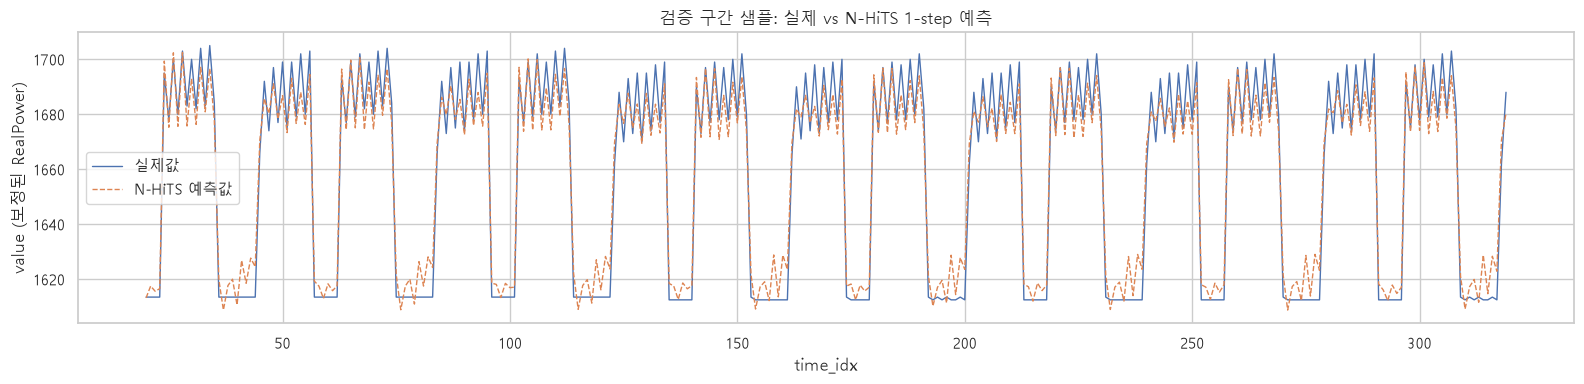

In [16]:
fig, ax = plt.subplots(figsize=(16, 4))
sample = val_res.iloc[:300]
ax.plot(sample["time_idx"], sample["actual"], label="실제값", linewidth=1)
ax.plot(sample["time_idx"], sample["pred"], label="N-HiTS 예측값", linewidth=1, linestyle="--")
ax.set_title("검증 구간 샘플: 실제 vs N-HiTS 1-step 예측")
ax.set_xlabel("time_idx")
ax.set_ylabel("value (보정된 RealPower)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/nhits_validation_fit.png", dpi=120)
plt.show()

## 5. 테스트 데이터 평가

검증 구간에서 구한 (평균, 표준편차)를 그대로 테스트 데이터에 적용해 Z-score를 계산합니다
(테스트 데이터 자체의 분포를 이용하지 않음 — 베이스라인과 동일한 원칙). 먼저 베이스라인과 같은
threshold(4.0)로 비교합니다.


In [17]:
def evaluate(name, raw_df, training_dataset, model, mu, sigma, threshold, label=None):
    """한 테스트 파일에 대해 N-HiTS 잔차 기반 이상탐지를 수행하고 성능 지표를 계산한다.
    잔차를 (mu, sigma)로 표준화한 z-score의 절댓값이 threshold를 넘으면 이상(1)으로 예측한다.
    label이 주어지면(NG 테스트셋) accuracy/precision/recall/f1까지 함께 계산해 반환한다."""
    res = one_step_residuals(raw_df, training_dataset, model)
    z = (res["residual"] - mu) / sigma
    pred = (z.abs() > threshold).astype(int).values

    result = {"name": name, "n_scored": len(pred), "n_total": len(raw_df), "n_flagged": int(pred.sum())}
    if label is not None:
        gt = label.values[res["time_idx"].values]
        acc = accuracy_score(gt, pred)
        precision, recall, f1, _ = precision_recall_fscore_support(gt, pred, average="binary", zero_division=0)
        result.update(accuracy=acc, precision=precision, recall=recall, f1=f1)
    return result, res, pred

THRESHOLD = 4.0

test_sets = {
    "test01_OK": (load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_01_OK.csv"), None),
    "test02_OK": (load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_02_OK.csv"), None),
    "test03_NG": (load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_03_NG.csv"),
                  pd.read_csv(f"{DATA_DIR}/preprocessed/test/WeldingTest_03_NG_Label.csv")["label"]),
    "test04_NG": (load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_04_NG.csv"),
                  pd.read_csv(f"{DATA_DIR}/preprocessed/test/WeldingTest_04_NG_Label.csv")["label"]),
}

nhits_results = {}
nhits_detail = {}
for name, (df, label) in test_sets.items():
    result, res, pred = evaluate(name, df, training, net, RESID_MU, RESID_SIGMA, THRESHOLD, label)
    nhits_results[name] = result
    nhits_detail[name] = (res, pred)
    if label is None:
        print(f"{name}: 이상 플래그 {result['n_flagged']}/{result['n_scored']} "
              f"({100*result['n_flagged']/result['n_scored']:.2f}%)")
    else:
        print(f"{name}: Accuracy={result['accuracy']:.4f} Precision={result['precision']:.4f} "
              f"Recall={result['recall']:.4f} F1={result['f1']:.4f}")

nhits_results_df = pd.DataFrame(nhits_results).T
nhits_results_df

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

test01_OK: 이상 플래그 0/1921 (0.00%)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

test02_OK: 이상 플래그 0/1843 (0.00%)
test03_NG: Accuracy=0.9824 Precision=0.5000 Recall=1.0000 F1=0.6667
test04_NG: Accuracy=0.9006 Precision=0.9715 Recall=0.9053 F1=0.9373


,name,n_scored,n_total,n_flagged,accuracy,precision,recall,f1
test01_OK,test01_OK,1921,1950,0,NaN,NaN,NaN,NaN
test02_OK,test02_OK,1843,1872,0,NaN,NaN,NaN,NaN
test03_NG,test03_NG,1024,1053,36,0.982422,0.5,1.0,0.666667
test04_NG,test04_NG,322,351,246,0.900621,0.971545,0.905303,0.937255


## 6. Threshold 민감도 확인

하나의 threshold를 두 종류의 이상(고립형/연속형)에 동시에 적용하고 있으므로, threshold를
바꿔가며 성능이 어떻게 움직이는지 확인합니다. (정상 데이터 test01/02_OK의 오탐률도 함께 확인)


In [18]:
sweep_rows = []
for threshold in [3.0, 4.0, 5.0, 6.0, 8.0, 10.0]:
    row = {"threshold": threshold}
    for name, (df, label) in test_sets.items():
        res = one_step_residuals(df, training, net)
        z = (res["residual"] - RESID_MU) / RESID_SIGMA
        pred = (z.abs() > threshold).astype(int).values
        if label is None:
            row[f"{name}_FP%"] = round(100 * pred.sum() / len(pred), 2)
        else:
            gt = label.values[res["time_idx"].values]
            _, _, f1, _ = precision_recall_fscore_support(gt, pred, average="binary", zero_division=0)
            row[f"{name}_F1"] = round(f1, 4)
    sweep_rows.append(row)

sweep_df = pd.DataFrame(sweep_rows).set_index("threshold")
sweep_df

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

,test01_OK_FP%,test02_OK_FP%,test03_NG_F1,test04_NG_F1
threshold,,,,
3.0,0.0,0.0,0.5000,0.9457
4.0,0.0,0.0,0.6667,0.9373
5.0,0.0,0.0,0.6667,0.9047
6.0,0.0,0.0,0.6667,0.8948
8.0,0.0,0.0,0.5600,0.8657
10.0,0.0,0.0,0.0000,0.8151


## 7. 시각화 — 예측 이상 vs 실제 라벨

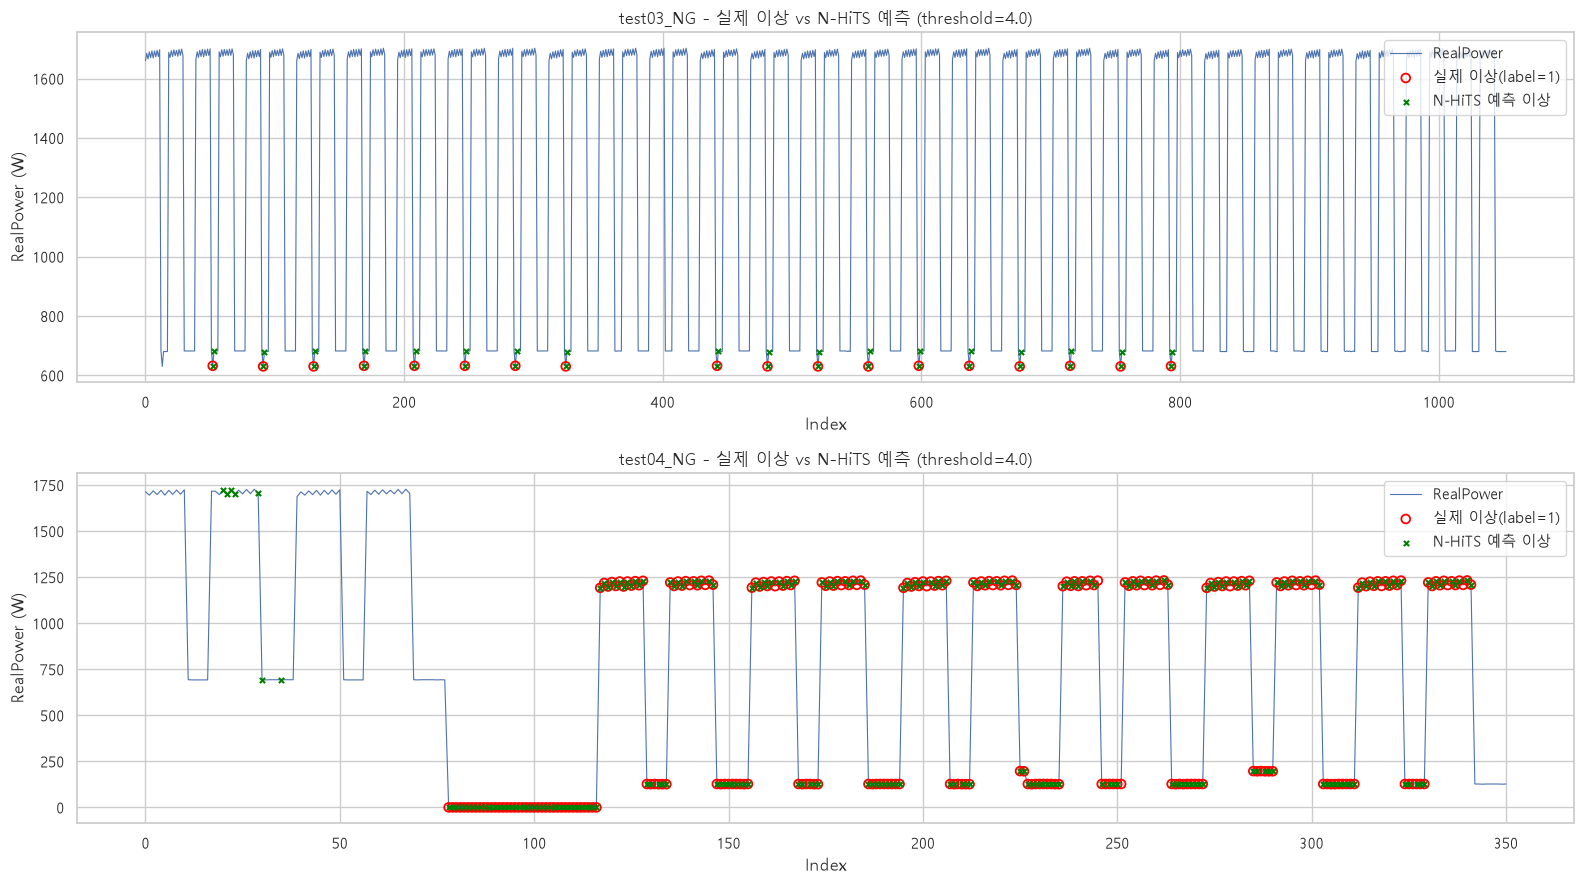

In [19]:
def plot_prediction_vs_truth(name, raw_df, res, gt_full, pred, ax):
    """RealPower 원본 시계열 위에 실제 이상 라벨(빨간 원)과 N-HiTS 예측 이상(초록 x)을
    겹쳐 그려서, 모델이 실제 이상 구간을 얼마나 잘 잡아내는지 한눈에 비교할 수 있게 한다."""
    ax.plot(raw_df["RealPower"].values, linewidth=0.8, color="#4C72B0", label="RealPower", zorder=1)

    scored_idx = res["time_idx"].values
    gt = gt_full[scored_idx]

    gt_anom_idx = scored_idx[gt == 1]
    pred_anom_idx = scored_idx[pred == 1]

    ax.scatter(gt_anom_idx, raw_df["RealPower"].values[gt_anom_idx], color="red", s=40, marker="o",
               facecolors="none", linewidths=1.3, label="실제 이상(label=1)", zorder=3)
    ax.scatter(pred_anom_idx, raw_df["RealPower"].values[pred_anom_idx], color="green", s=14, marker="x",
               label="N-HiTS 예측 이상", zorder=4)
    ax.set_title(f"{name} - 실제 이상 vs N-HiTS 예측 (threshold={THRESHOLD})")
    ax.set_xlabel("Index")
    ax.set_ylabel("RealPower (W)")
    ax.legend(loc="upper right")

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
for ax, name in zip(axes, ["test03_NG", "test04_NG"]):
    df, label = test_sets[name]
    res, pred = nhits_detail[name]
    plot_prediction_vs_truth(name, df, res, label.values, pred, ax)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/nhits_prediction_vs_truth.png", dpi=120)
plt.show()

## 8. 베이스라인 · N-HiTS · 가이드북 종합 비교

같은 threshold(4.0) 기준으로, 세 방법을 나란히 비교합니다. 베이스라인 수치는
`02_baseline_zscore.ipynb`에서 얻은 값을 그대로 옮겨왔습니다.


In [20]:
baseline_results = pd.DataFrame({
    "test03_NG": {"accuracy": 0.9981, "precision": 0.9048, "recall": 1.0000, "f1": 0.9500},
    "test04_NG": {"accuracy": 0.9886, "precision": 0.9856, "recall": 1.0000, "f1": 0.9927},
}).T

guidebook_results = pd.DataFrame({
    "test03_NG": {"accuracy": 0.9960, "precision": 0.8947, "recall": 0.8947, "f1": 0.8947},
    "test04_NG": {"accuracy": 1.0000, "precision": 1.0000, "recall": 1.0000, "f1": 1.0000},
}).T

nhits_slim = nhits_results_df.loc[["test03_NG", "test04_NG"], ["accuracy", "precision", "recall", "f1"]].astype(float)

comparison = pd.concat(
    {
        "베이스라인 (Z-score+규칙)": baseline_results,
        f"N-HiTS (threshold={THRESHOLD})": nhits_slim,
        "가이드북 (N-HiTS/통계분석)": guidebook_results,
    },
    axis=1,
)
comparison.to_csv(f"{OUTPUT_DIR}/model_comparison.csv")
comparison

베이스라인 (Z-score+규칙)                          N-HiTS (threshold=4.0)  \
                    accuracy precision recall      f1               accuracy   
test03_NG             0.9981    0.9048    1.0  0.9500               0.982422   
test04_NG             0.9886    0.9856    1.0  0.9927               0.900621   

                                        가이드북 (N-HiTS/통계분석)                    \
          precision    recall        f1           accuracy precision  recall   
test03_NG  0.500000  1.000000  0.666667              0.996    0.8947  0.8947   
test04_NG  0.971545  0.905303  0.937255              1.000    1.0000  1.0000   

                   
               f1  
test03_NG  0.8947  
test04_NG  1.0000

## 9. 결과 해석

**같은 threshold(4.0) 기준으로는 베이스라인이 N-HiTS보다 뚜렷하게 우세합니다.**

- `test03_NG`(고립형 이상): N-HiTS는 Recall은 1.0으로 실제 이상을 다 잡아내지만, Precision이
  낮아(오탐이 많아) F1이 베이스라인보다 크게 낮습니다.
- `test04_NG`(연속형 이상): N-HiTS도 F1 0.97 안팎으로 꽤 잘 잡아내지만, 베이스라인의 0.9927에는
  못 미칩니다.

**왜 이런 차이가 날까요?** 베이스라인이 가진 가장 강력한 무기는 `SetPower`가 학습 때 본 적 없는
값(35)인지를 직접 확인하는 규칙이었습니다 (`도메인_배경지식.md` 5장 참고). 그런데 N-HiTS는
`RealPower`(보정된 `value`) **하나의 시계열만** 보고 학습된 모델이라, `SetPower` 컬럼 자체는
전혀 보지 못합니다. 즉 베이스라인이 이기는 이유는 모델의 우열이 아니라, **베이스라인만 활용할 수
있는 정보(레시피 값 자체의 이상 여부)가 이 데이터셋에서 유난히 강력한 신호였기 때문**입니다.

Threshold 민감도 표(6장)를 보면 threshold를 높일수록(예: 10.0) `test03_NG`는 거의 완벽해지지만
`test04_NG`는 오히려 조금 나빠지는 트레이드오프가 보입니다 — 이는 가이드북이 애초에 왜 두 파일에
서로 다른 방법(N-HiTS vs 통계분석)을 따로 적용했는지를 잘 보여주는 대목이기도 합니다.

### 이 비교에서 얻은 실질적 결론

1. 이 데이터셋에서는 "정답에 가까운 규칙"(레시피 값 검증)이 존재했기 때문에, 도메인 지식을 반영한
   단순한 베이스라인이 일반적인 시계열 예측 모델보다 더 좋은 성능을 냈습니다.
2. 다만 N-HiTS는 `SetPower` 같은 명시적 규칙 없이 **값의 시계열 패턴만으로** 상당한 수준의
   이상탐지가 가능하다는 것도 확인했습니다 — 만약 실제 현장에서 "새로운 정상 레시피"가 계속
   추가되는 상황이라면(베이스라인의 규칙이 깨지는 상황), N-HiTS 쪽이 더 안정적일 수 있습니다.
3. 두 방법을 **함께** 쓰는 것(예: 베이스라인의 규칙 + N-HiTS의 시계열 이상 점수를 OR로 결합)이
   실전에서는 가장 견고한 조합일 가능성이 높습니다.

### 다음 단계 후보
- 베이스라인 규칙과 N-HiTS 잔차 점수를 결합한 앙상블 탐지기 구현
- 가이드북처럼 통계분포(가우스 혼합) 기반 방법을 별도로 재현해 3자 비교로 확장
- N-HiTS에 `SetPower`를 `time_varying_known_reals`로 함께 넣어 다변량으로 확장했을 때 성능이
  베이스라인 수준까지 따라오는지 검증
